# CS 598 Coding Assignment 2 
Students: Zarmeen Hasan 

## Problem 1

### a) Generate the dataset: 

In [29]:
import numpy as np
import pandas as pd 

np.random.seed(598)

n, p = 1000, 20
X = np.random.randn(n, p)
beta = np.array([1, 0.5, 0, -0.5, -1, 1, 0.5, 2, 0, 0, 0.1, 0.2, 2, 0, 0, 0, -2, 1, 0, 0])
epsilon = np.random.randn(n)
Y = X @ beta + epsilon

df = pd.DataFrame(X, columns=[f"X{i+1}" for i in range(p)])
df["Y"] = Y
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X12,X13,X14,X15,X16,X17,X18,X19,X20,Y
0,0.631817,0.992217,0.814855,0.508294,-3.049325,0.579123,-1.004465,0.946470,0.480146,0.172392,...,2.262867,0.144101,0.682657,-1.034275,1.666798,0.217080,0.791525,0.274771,1.166617,7.639546
1,-0.234107,0.930885,-0.760648,-0.176433,-1.177487,0.542030,0.243152,-0.589136,0.832404,0.040634,...,0.705187,0.794501,-0.198866,0.098521,-0.272778,-0.027863,-0.890903,0.692273,1.027067,3.584085
2,0.340059,0.083840,-1.283234,2.203682,0.487924,1.203680,-0.630128,0.680380,0.013294,0.626000,...,1.623584,-0.860767,-1.311733,-1.432396,0.529256,0.679941,-0.783687,-1.724416,0.142406,-1.473419
3,0.885201,0.475417,0.816489,-0.167170,0.501055,0.582894,-1.104299,0.054106,0.016298,0.243096,...,-0.992252,1.179075,-1.355704,-0.327499,-2.134424,0.402037,0.456633,-0.804669,-0.298952,2.400951
4,-0.032399,-0.501859,-1.076201,0.171454,-0.428932,-0.815681,1.903563,0.420651,-0.331723,1.775640,...,1.679375,1.790486,-1.819201,0.231464,-0.334071,-0.992247,0.310303,0.421970,0.307662,8.492526


### b) Split data into training and testing datasets:

In [30]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="Y")  
y = df["Y"]              

# Set test_size to 20% to get 200 observations in the testing set. 
# Remaining 80% (800 observations) are the training set. 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20
29,1.033713,1.190242,1.336018,0.063029,-0.589914,0.937168,2.309337,-1.100633,0.527706,0.285060,-0.752919,-0.616779,-0.102591,0.514395,0.762127,2.108920,0.136564,1.344216,1.407178,0.211994
535,-0.380036,0.779319,0.168434,0.429030,0.347470,-0.407331,0.233228,-0.204163,0.223019,-0.983750,-0.460072,0.374914,-0.664209,1.190256,0.691154,-1.034506,1.166199,0.579359,-0.189461,0.131721
695,0.442080,-0.992404,0.805779,1.642769,-0.398109,-0.809849,0.474631,-0.235647,0.452964,-2.049983,2.320549,-0.759088,-1.381314,0.000421,0.016487,0.889981,-0.580581,0.398022,-0.284332,0.105929
557,1.266945,-0.822843,0.879377,0.407113,-1.234773,0.115534,-0.059079,0.171666,1.525265,0.667455,-1.035496,0.584116,-0.491647,1.016874,1.373780,-0.464129,1.612121,-0.578113,-1.093553,1.435558
836,-0.315432,0.718610,1.075027,-0.777464,-0.974428,-0.294846,-0.236013,0.525198,0.088985,0.751901,-1.324489,-0.997587,-0.034306,-0.295051,-0.951999,0.051569,0.253047,-0.893934,0.450229,0.748544


In [31]:
y_train.head()

29     1.701962
535   -5.732403
695   -2.009361
557   -5.440350
836    1.669447
Name: Y, dtype: float64

### c) Perform best subset selection on training set & plot training MSE: 

Because Python doesn't have functionality similar to R's `regsubset`, I decided to perform Forward Selection using BIC as my scorer. To implement this, I created a custom BIC scorer function and passed that into `mlxtend.feature_selection`'s `SequentialFeatureSelector`.

In [32]:
from sklearn.linear_model import LinearRegression
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

def bic_scorer(estimator, X, y):
    n, k = X.shape
    y_pred = estimator.predict(X)
    rss = np.sum((y - y_pred) ** 2)
    bic = n * np.log(rss / n) + (k + 1) * np.log(n)
    return -bic 

# Forward selection with BIC
lr = LinearRegression()
sfs = SFS(
    estimator=lr,
    k_features="best",
    forward=True,
    floating=False,
    scoring=bic_scorer,
    cv=0
)

sfs = sfs.fit(X_train, y_train)

print("Selected features (Using BIC):", sfs.k_feature_names_)


Selected features (Using BIC): ('X1', 'X2', 'X4', 'X5', 'X6', 'X7', 'X8', 'X11', 'X12', 'X13', 'X17', 'X18')


The selected model will ahve the above features. I will now calculate the training MSE's using this selected model.

In [33]:
def calculate_mse(estimator, X, y):
    y_pred = estimator.predict(X)
    return np.mean((y - y_pred) ** 2)

mse_values = []
for subset in sfs.subsets_.values():
    features = list(subset["feature_idx"])
    model = LinearRegression().fit(X_train.iloc[:, features], y_train)
    mse_values.append(calculate_mse(model, X_train.iloc[:, features], y_train))

print("Training MSE Values:")
for mse in mse_values: 
    print("   ", mse)

Training MSE Values:
    12.41292504236832
    9.02782227617385
    5.6258535619367
    4.623338712427269
    3.6462921729184607
    2.7870647555855044
    1.9099465164813136
    1.5764788609872682
    1.2899802228021247
    1.1019916842597395
    1.0681304113699248
    1.0588322277608335
    1.0549158599125883
    1.0519703878018971
    1.0494950671954129
    1.048827073006225
    1.0483656219256272
    1.0479312388603512
    1.0477965013630066
    1.0476816774191513


Plot the Training MSE by number of features (k):

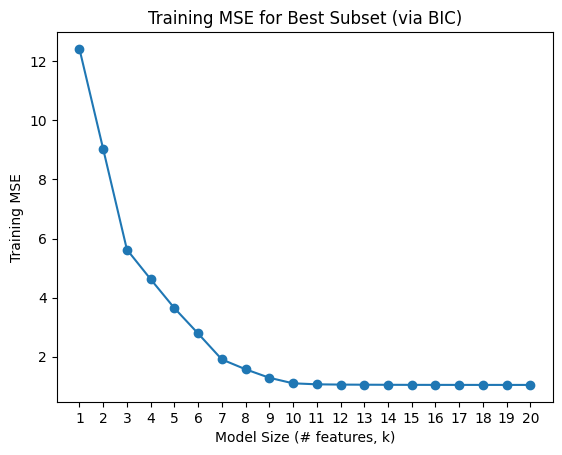

In [34]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(mse_values)+1), mse_values, marker="o")
plt.xlabel("Model Size (# features, k)")
plt.ylabel("Training MSE")
plt.xticks(ticks=range(1, 21))
plt.title("Training MSE for Best Subset (via BIC)")
plt.show()

### d) Plot testing MSE: 

I calculated the testing MSE using the `calculate_mse()`function defined in part c. 

In [35]:
test_mse_values = []
for subset in sfs.subsets_.values():
    features = list(subset["feature_idx"])
    model = LinearRegression().fit(X_train.iloc[:, features], y_train)
    test_mse_values.append(calculate_mse(model, X_test.iloc[:, features], y_test))

print("Testing MSE Values:")
for mse in test_mse_values: 
    print("   ", mse)

Testing MSE Values:
    11.171190835362365
    8.700765703941896
    5.633749693706474
    4.9872141810473885
    3.935303328358475
    2.918117208061208
    1.865335585626878
    1.408357665662766
    1.2127998950398693
    0.9713124025238611
    0.9797440674467862
    0.9768770869564315
    0.9789312390332086
    0.9878461338549859
    0.9950337678823317
    0.995067945832702
    0.9973847409194463
    1.00317459879853
    1.0040387201419279
    1.0059459404034785


Plot the Testing MSE values against the number of featuers (k): 

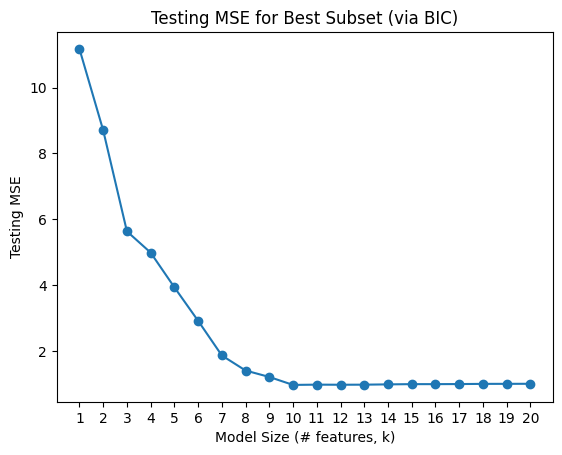

In [36]:
plt.plot(range(1, len(test_mse_values)+1), test_mse_values, marker="o")
plt.xlabel("Model Size (# features, k)")
plt.ylabel("Testing MSE")
plt.xticks(ticks=range(1, 21))
plt.title("Testing MSE for Best Subset (via BIC)")
plt.show()

### e) Minimum Test MSE

The test set MSE reaches its minimum when the model contains 10 features. This suggests that including the first 10 features gives the best balance between underfitting and overfitting for this dataset. Models with less than 10 features likely underfit, which increases the error. Models with more than 10 features may start to overfit, capturing noise in the training data that does not generalize to the test set, which also increases the test MSE.

This pattern aligns with the bias-variance tradeoff: adding features reduces bias but increases variance, so the best model is attained using a subset of features.

### f) How does the model at which the test set MSE is minimized compare to the true model used to generate the data?

Let's take a look at my fitted model's coefficient values: 


In [37]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 0.04432488106520424
Coefficients: [ 0.9888287   0.48631503 -0.05518159 -0.53445155 -1.04274197  0.927961
  0.53264167  1.97315558 -0.06277975  0.0231183   0.09645455  0.19272112
  2.00978855 -0.05207204 -0.02490858  0.01231036 -2.0284346   0.98367873
  0.02199728 -0.01040544]


Now let's compare my fitted model's coefficients with the true betas I used to generate the dataset: 

In [38]:
comparison = pd.DataFrame({
    "Feature": [f"X{i+1}" for i in features],
    "Estimated Beta": model.coef_,
    "True Beta": beta[features]
})

comparison

,Feature,Estimated Beta,True Beta
0,X1,0.988829,1.0
1,X2,0.486315,0.5
2,X3,-0.055182,0.0
3,X4,-0.534452,-0.5
4,X5,-1.042742,-1.0
5,X6,0.927961,1.0
6,X7,0.532642,0.5
7,X8,1.973156,2.0
8,X9,-0.062780,0.0
9,X10,0.023118,0.0


From the above table, you can see that the fitted model's estimated coefficient values are pretty close to the true beta values. This shows that feature selection successfully identifies the important predictors and avoids overfitting.

### g) Compute coefficient error for each model size `r`

We first calculate the errors: 

In [39]:
errors = []

for r, subset in sfs.subsets_.items():
    features = list(subset["feature_idx"])
    model = LinearRegression().fit(X_train.iloc[:, features], y_train)

    # Initialize all estimates as 0 (for features not included in the model)
    est_beta = np.zeros(p)

    # Fill in the coefficients for the selected features
    est_beta[features] = model.coef_

    # Compute sum of squared differences from true beta
    error = np.sum((beta - est_beta)**2)
    errors.append(error)

print("First 3 errors: ", errors[:3])

First 3 errors:  [np.float64(12.82672057360317), np.float64(8.837769040342664), np.float64(4.838075988728562)]


Then plot the errors by r: 

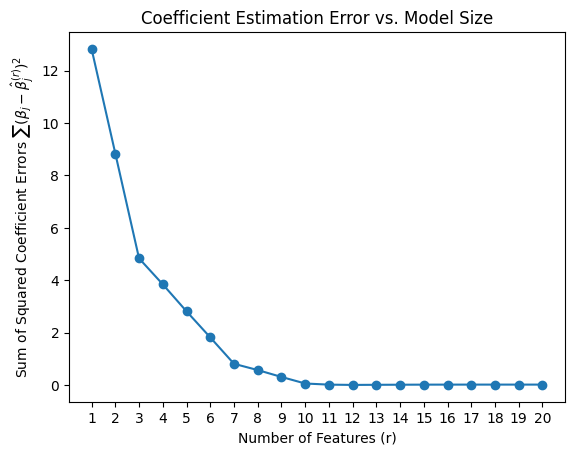

In [40]:
plt.plot(range(1, len(errors)+1), errors, marker="o")
plt.xlabel("Number of Features (r)")
plt.xticks(ticks=range(1, 21))
plt.ylabel(r"Sum of Squared Coefficient Errors $\sum (\beta_j - \hat{\beta}_j^{(r)})^2$")
plt.title("Coefficient Estimation Error vs. Model Size")
plt.show()

The coefficient error decreases rapidly as more features are added, since the model recovers more of the true nonzero coefficients. Around 𝑟=10, the error is minimized, which corresponds to the number of important predictors in the true model. Beyond this point, adding extra features increases variance without improving the estimates of the true betas, so the error levels off or slightly increases. This pattern is consistent with the test MSE plot, where the best predictive performance also occurred around r=10.

## Problem 2

Pre-work: Load the datasets as training and teesting dataframes. 

In [41]:
test_df = pd.read_csv("data/mls_test.csv")
train_df = pd.read_csv("data/mls_train.csv")

X_test, y_test = test_df.drop(columns=["salary"]), test_df["salary"]
X_train, y_train = train_df.drop(columns=["salary"]), train_df["salary"]

In [42]:
X_train.columns

Index(['height, cm', 'weight, kg', 'game_started', 'mins', 'sub_on',
       'total_wins', 'goals', 'duel_won', 'accurate_cross', 'assist',
       'yellow_card', 'won_tackle', 'aerial_won', 'ontarget_scoring_att',
       'successful_short_pass', 'won_corners', 'ball_recovery',
       'total_offside'],
      dtype='object')

In [43]:
y_train.head()

0    2360667
1    1080000
2     450000
3     460000
4     121303
Name: salary, dtype: int64

### a) Best Subset Selection

Using the same process I did in Problem 1c above, I will use BIC as my scorer for a forward selection. 

In [44]:
# Forward selection with BIC
sfs = SFS(
    LinearRegression(),
    k_features=8,
    forward=True,
    floating=False,
    scoring=bic_scorer,
    cv=0,        
)

sfs = sfs.fit(X_train, y_train)

In [45]:
results = []

for r, subset in sfs.subsets_.items():
    if r > 8:
        continue

    features = list(subset['feature_idx'])
    model = LinearRegression().fit(X_train.iloc[:, features], y_train)

    train_mse = np.mean((y_train - model.predict(X_train.iloc[:, features]))**2)
    test_mse = np.mean((y_test - model.predict(X_test.iloc[:, features]))**2)

    results.append({
        "Model Size": r,
        "Training MSE": round(train_mse, 3),
        "Test MSE": round(test_mse, 3),
        "Selected Features": "\n".join(X_train.columns[features]) 
    })

results_df = pd.DataFrame(results)

for i, row in results_df.iterrows():
    print(f"Model Size: {row['Model Size']}")
    print(f"Training MSE: {row['Training MSE']}")
    print(f"Test MSE    : {row['Test MSE']}")
    print("Selected Features:")
    print(row['Selected Features'])  
    print("-" * 40)


Model Size: 1
Training MSE: 325845456016.663
Test MSE    : 652107575276.923
Selected Features:
ontarget_scoring_att
----------------------------------------
Model Size: 2
Training MSE: 298999744800.577
Test MSE    : 674862372322.81
Selected Features:
ontarget_scoring_att
successful_short_pass
----------------------------------------
Model Size: 3
Training MSE: 284022572114.091
Test MSE    : 669796830254.868
Selected Features:
won_tackle
ontarget_scoring_att
successful_short_pass
----------------------------------------
Model Size: 4
Training MSE: 273248854325.324
Test MSE    : 670014294583.175
Selected Features:
won_tackle
aerial_won
ontarget_scoring_att
successful_short_pass
----------------------------------------
Model Size: 5
Training MSE: 267818652079.739
Test MSE    : 680458956958.788
Selected Features:
won_tackle
aerial_won
ontarget_scoring_att
successful_short_pass
total_offside
----------------------------------------
Model Size: 6
Training MSE: 262569679499.918
Test MSE    : 

### b) Model Comparison: AIC vs. BIC vs. $C_p$-Mallows vs. $R_a^2$
We already have a function to calcualte BIC: `bic_scorer()`. Here's a function to calculate AIC: 

In [46]:
def compute_aic(model, X, y):
    n = X.shape[0]
    k = X.shape[1] + 1  # include intercept
    rss = np.sum((y - model.predict(X))**2)
    return n * np.log(rss/n) + 2*k

And another function to calculate $C_p$-Mallows:

In [47]:
def compute_cp(model, X_subset, y, sigma2_hat):
    n = X_subset.shape[0]
    p_r = X_subset.shape[1] + 1  # include intercept
    rss_r = np.sum((y - model.predict(X_subset))**2)
    cp = rss_r / sigma2_hat - (n - 2 * p_r)
    return cp

We need to calculate $\hat{\sigma}^2$ for the full model in order to use `compute_cp()`:  

In [48]:
full_model = LinearRegression().fit(X_train, y_train)
rss_full = np.sum((y_train - full_model.predict(X_train))**2)
n, p = X_train.shape
sigma2_hat = rss_full / (n - p - 1)

Using the above functions, iterate through each of the models from part a and te a table with each metric. I'll use this table to ID the best model based on each of these metrics. 

In [49]:
enhanced_results = []

for row in results:
    features = row['Selected Features'].split("\n")
    idx = [X_train.columns.get_loc(f) for f in features]  # get column indices

    model = LinearRegression().fit(X_train.iloc[:, idx], y_train)

    aic = compute_aic(model, X_train.iloc[:, idx], y_train)
    bic = -bic_scorer(model, X_train.iloc[:, idx], y_train)
    r2 = model.score(X_train.iloc[:, idx], y_train)
    cp = compute_cp(model, X_train.iloc[:, idx], y_train, sigma2_hat)

    enhanced_results.append({
        "Model Size": row["Model Size"],
        "Training MSE": row["Training MSE"],
        "Test MSE": row["Test MSE"],
        "AIC": round(aic, 2),
        "BIC": round(bic, 2),
        "R2": round(r2, 2),
        "Cp": round(cp, 2)
    })

enhanced_results_df = pd.DataFrame(enhanced_results)
pd.set_option("display.max_colwidth", None)
enhanced_results_df

,Model Size,Training MSE,Test MSE,AIC,BIC,R2,Cp
0,1,3.258455e+11,6.521076e+11,9441.45,9449.20,0.30,90.86
1,2,2.989997e+11,6.748624e+11,9412.84,9424.47,0.36,56.37
2,3,2.840226e+11,6.697968e+11,9396.55,9412.05,0.39,38.01
3,4,2.732489e+11,6.700143e+11,9384.78,9404.15,0.41,25.37
4,5,2.678187e+11,6.804590e+11,9379.63,9402.88,0.42,19.99
5,6,2.625697e+11,6.802184e+11,9374.59,9401.71,0.44,14.86
6,7,2.590164e+11,6.792259e+11,9371.74,9402.74,0.44,12.03
7,8,2.556718e+11,6.661950e+11,9369.11,9403.98,0.45,9.48


Based on the table above and the one from part a, the following models are the best based on each metric: 

| Criterion       | Best Model Size | Training MSE    | Test MSE        | Notes         |
| --------------- | --------------- | --------------- | --------------- | ------------- |
| **AIC**         | 8               | 2.556718 × 10¹¹ | 6.661950 × 10¹¹ | Lowest AIC    |
| **BIC**         | 6               | 2.625697 × 10¹¹ | 6.802184 × 10¹¹ | Lowest BIC    |
| **Cp-Mallows**  | 8               | 2.556718 × 10¹¹ | 6.661950 × 10¹¹ | Cp ≈ p\_r + 1 |
| **Adjusted R²** | 8               | 2.556718 × 10¹¹ | 6.661950 × 10¹¹ | Highest R²    |


### c) Ridge Regression

In [51]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

lambdas = np.logspace(-4, 4, 100) 

ridge_cv = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=lambdas, cv=5, scoring='neg_mean_squared_error')
)

ridge_cv.fit(X_train, y_train)

best_lambda = ridge_cv.named_steps['ridgecv'].alpha_
print("Best λ:", best_lambda)

Best λ (alpha): 25.950242113997373


In [52]:
y_train_pred = ridge_cv.predict(X_train)
y_test_pred = ridge_cv.predict(X_test)

train_mse = np.mean((y_train - y_train_pred)**2)
test_mse = np.mean((y_test - y_test_pred)**2)

print("Training MSE:", train_mse)
print("Test MSE:", test_mse)

Training MSE: 253016991144.07742
Test MSE: 638314094075.6617


### d) Lasso

Fit the Lasso regression and find the best λ:

In [70]:
from sklearn.linear_model import LassoCV

alphas = np.logspace(-4, 4, 100)  

lasso_cv = make_pipeline(
    StandardScaler(),
    LassoCV(
        alphas=alphas,
        cv=5,           
        max_iter=10000000,  # increase iterations to ensure convergence
        random_state=42
    )
)

lasso_cv.fit(X_train, y_train)

best_alpha = lasso_cv.named_steps['lassocv'].alpha_
print("Best alpha for Lasso:", best_alpha)

Best alpha for Lasso: 5722.3676593502205


In [71]:
y_train_pred = lasso_cv.predict(X_train)
y_test_pred = lasso_cv.predict(X_test)

train_mse = np.mean((y_train - y_train_pred)**2)
test_mse = np.mean((y_test - y_test_pred)**2)

print("Lasso Training MSE:", train_mse)
print("Lasso Test MSE:", test_mse)

Lasso Training MSE: 250560314484.02747
Lasso Test MSE: 642304208642.7651


Identify the coefficients that shrunk to 0: 

In [67]:
coef = lasso_cv.named_steps['lassocv'].coef_
feature_coef = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': coef
})

zero_features = feature_coef[feature_coef['Coefficient'] == 0]['Feature'].tolist()
print("Features shrunk to zero by Lasso:", zero_features)


Features shrunk to zero by Lasso: ['height, cm', 'game_started', 'mins', 'yellow_card']


### e) Comparing models in part b vs. ridge vs. lasso 

| Model / Criterion        | Model Size | Training MSE    | Test MSE        | Notes               |
| ------------------------ | ---------- | --------------- | --------------- | ------------------- |
| **Best Subset (AIC)**    | 8          | 2.556718 × 10¹¹ | 6.661950 × 10¹¹ | Lowest AIC          |
| **Best Subset (BIC)**    | 6          | 2.625697 × 10¹¹ | 6.802184 × 10¹¹ | Lowest BIC          |
| **Best Subset (Cp)**     | 8          | 2.556718 × 10¹¹ | 6.661950 × 10¹¹ | Cp ≈ p\_r + 1       |
| **Best Subset (Adj R²)** | 8          | 2.556718 × 10¹¹ | 6.661950 × 10¹¹ | Highest Adjusted R² |
| **Ridge Regression**     | –          | 2.530169 × 10¹¹ | 6.383141 × 10¹¹ | Best λ via CV       |
| **Lasso Regression**     | –          | 2.505603 × 10¹¹ | 6.423042 × 10¹¹ | Best α via CV       |


Based on the above results, I would suggest using Ridge regression for predicting MLS salaries because it has the lowest Test MSE value. Lasso's Test MSE is close but still higher than Ridge. The other Test MSE's are higher which presents a risk of overfitting. 